In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Latex

sns.set_style('whitegrid')

from sklearn.preprocessing import LabelEncoder
from sklearn import model_selection
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import f1_score, accuracy_score

In [ ]:
df_loan = pd.read_csv("/content/loan.csv")
df_loan.head(7)

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,1077501,1296599,5000.0,5000.0,4975.0,36 months,10.65,162.87,B,B2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1077430,1314167,2500.0,2500.0,2500.0,60 months,15.27,59.83,C,C4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1077175,1313524,2400.0,2400.0,2400.0,36 months,15.96,84.33,C,C5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1076863,1277178,10000.0,10000.0,10000.0,36 months,13.49,339.31,C,C1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1075358,1311748,3000.0,3000.0,3000.0,60 months,12.69,67.79,B,B5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,1075269,1311441,5000.0,5000.0,5000.0,36 months,7.90,156.46,A,A4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,1069639,1304742,7000.0,7000.0,7000.0,60 months,15.96,170.08,C,C5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df_loan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20837 entries, 0 to 20836
Data columns (total 74 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           20837 non-null  int64  
 1   member_id                    20837 non-null  int64  
 2   loan_amnt                    20837 non-null  float64
 3   funded_amnt                  20837 non-null  float64
 4   funded_amnt_inv              20837 non-null  float64
 5   term                         20837 non-null  object 
 6   int_rate                     20837 non-null  float64
 7   installment                  20837 non-null  float64
 8   grade                        20837 non-null  object 
 9   sub_grade                    20837 non-null  object 
 10  emp_title                    19452 non-null  object 
 11  emp_length                   20107 non-null  object 
 12  home_ownership               20837 non-null  object 
 13  annual_inc      

In [ ]:
# Replace the problematic line with:
df_loan.drop(columns=df_loan.columns.difference(['loan_amnt','term','int_rate','installment','grade','emp_length','home_ownership','annual_inc','verification_status','loan_status','purpose']), inplace=True)
# The 'columns' keyword argument is used to specify the columns to drop.
# 'inplace=True' modifies the DataFrame directly, avoiding the need for reassignment.

In [ ]:
df_loan.isnull().sum()

,0
loan_amnt,0
term,0
int_rate,0
installment,0
grade,0
emp_length,730
home_ownership,0
annual_inc,0
verification_status,0
loan_status,0


In [ ]:
df_loan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20837 entries, 0 to 20836
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   loan_amnt            20837 non-null  float64
 1   term                 20837 non-null  object 
 2   int_rate             20837 non-null  float64
 3   installment          20837 non-null  float64
 4   grade                20837 non-null  object 
 5   emp_length           20107 non-null  object 
 6   home_ownership       20837 non-null  object 
 7   annual_inc           20837 non-null  float64
 8   verification_status  20837 non-null  object 
 9   loan_status          20837 non-null  object 
 10  purpose              20836 non-null  object 
dtypes: float64(4), object(7)
memory usage: 1.7+ MB


In [ ]:
df_loan.head(10)

,loan_amnt,term,int_rate,installment,grade,emp_length,home_ownership,annual_inc,verification_status,loan_status,purpose
0,5000.0,36 months,10.65,162.87,B,10+ years,RENT,24000.0,Verified,Fully Paid,credit_card
1,2500.0,60 months,15.27,59.83,C,< 1 year,RENT,30000.0,Source Verified,Charged Off,car
2,2400.0,36 months,15.96,84.33,C,10+ years,RENT,12252.0,Not Verified,Fully Paid,small_business
3,10000.0,36 months,13.49,339.31,C,10+ years,RENT,49200.0,Source Verified,Fully Paid,other
4,3000.0,60 months,12.69,67.79,B,1 year,RENT,80000.0,Source Verified,Current,other
5,5000.0,36 months,7.90,156.46,A,3 years,RENT,36000.0,Source Verified,Fully Paid,wedding
6,7000.0,60 months,15.96,170.08,C,8 years,RENT,47004.0,Not Verified,Current,debt_consolidation
7,3000.0,36 months,18.64,109.43,E,9 years,RENT,48000.0,Source Verified,Fully Paid,car
8,5600.0,60 months,21.28,152.39,F,4 years,OWN,40000.0,Source Verified,Charged Off,small_business
9,5375.0,60 months,12.69,121.45,B,< 1 year,RENT,15000.0,Verified,Charged Off,other


In [ ]:
df_loan.annual_inc = df_loan.annual_inc.fillna(0)
df_loan.isnull().sum()

,0
loan_amnt,0
term,0
int_rate,0
installment,0
grade,0
emp_length,730
home_ownership,0
annual_inc,0
verification_status,0
loan_status,0


In [ ]:
status = df_loan['loan_status'].unique()
status

array(['Fully Paid', 'Charged Off', 'Current', 'Default',
       'Late (31-120 days)', 'In Grace Period', 'Late (16-30 days)'],
      dtype=object)

1.   Fully Paid: Tamamen Ödenmiş
2.   Does not meet the credit policy. Status: Fully Paid: Kredi politikalarına uygun değil. Durum: Tamamen Ödenmiş
3.   Current: Güncel
4.   Late (31-120 days): Gecikmiş (31-120 gün)
5.   Late (16-30 days): Gecikmiş (16-30 gün)
6.   In Grace Period: İhtar Süresinde
7.   Charged Off: Zarar Yazılmış
8.   Default: Temerrüde Düşmüş
9.   Does not meet the credit policy. Status: Charged Off: Kredi politikalarına uygun değil. Durum: Zarar Yazılmış
10.   Issued: Verilmiş / Çıkarılmış

In [ ]:
# binary classification
label_categories = [
    (0, ['Fully Paid', 'Does not meet the credit policy. Status:Fully Paid', 'Current', 'Issued']),
    (1, ['Late (31-120 days)', 'Late (16-30 days)', 'In Grace Period',
         'Charged Off', 'Default', 'Does not meet the credit policy. Status:Charged Off'])
]

In [ ]:
# function to apply the transformation
def classify_label(text):
    for category, matches in label_categories:
        if any(match in text for match in matches):
            return category
    return None

In [ ]:
df_loan.loc[:, 'label'] = df_loan['loan_status'].apply(classify_label)
df_loan = df_loan.drop('loan_status', axis=1)

In [ ]:
# label several label with specific grading system.
def SC_LabelEncoder1(text):
    if text == "E":
        return 1
    elif text == "D":
        return 2
    elif text == "C":
        return 3
    elif text == "B":
        return 4
    elif text == "A":
        return 5
    else:
        return 0


def SC_LabelEncoder2(text):
    if text == "< 1 year":
        return 1
    elif text == "1 year":
        return 2
    elif text == "2 years":
        return 3
    elif text == "3 years":
        return 4
    elif text == "4 years":
        return 5
    elif text == "5 years":
        return 6
    elif text == "6 years":
        return 7
    elif text == "7 years":
        return 8
    elif text == "8 years":
        return 9
    elif text == "9 years":
        return 10
    elif text == "10 years":
        return 11
    elif text == "10+ years":
        return 12
    else:
        return 0

def SC_LabelEncoder3(text):
    if text == "RENT":
        return 1
    elif text == "MORTGAGE":
        return 2
    elif text == "OWN":
        return 3
    else:
        return 0

df_loan["grade"] = df_loan["grade"].apply(SC_LabelEncoder1)
df_loan["emp_length"] = df_loan["emp_length"].apply(SC_LabelEncoder2)
df_loan["home_ownership"] = df_loan["home_ownership"].apply(SC_LabelEncoder3)

In [ ]:
df_loan.head(10)

,loan_amnt,term,int_rate,installment,grade,emp_length,home_ownership,annual_inc,verification_status,purpose,label
0,5000.0,36 months,10.65,162.87,4,12,1,24000.0,Verified,credit_card,0
1,2500.0,60 months,15.27,59.83,3,1,1,30000.0,Source Verified,car,1
2,2400.0,36 months,15.96,84.33,3,12,1,12252.0,Not Verified,small_business,0
3,10000.0,36 months,13.49,339.31,3,12,1,49200.0,Source Verified,other,0
4,3000.0,60 months,12.69,67.79,4,2,1,80000.0,Source Verified,other,0
5,5000.0,36 months,7.90,156.46,5,4,1,36000.0,Source Verified,wedding,0
6,7000.0,60 months,15.96,170.08,3,9,1,47004.0,Not Verified,debt_consolidation,0
7,3000.0,36 months,18.64,109.43,1,10,1,48000.0,Source Verified,car,0
8,5600.0,60 months,21.28,152.39,0,5,3,40000.0,Source Verified,small_business,1
9,5375.0,60 months,12.69,121.45,4,1,1,15000.0,Verified,other,1


In [ ]:
df_loan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20837 entries, 0 to 20836
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   loan_amnt            20837 non-null  float64
 1   term                 20837 non-null  object 
 2   int_rate             20837 non-null  float64
 3   installment          20837 non-null  float64
 4   grade                20837 non-null  int64  
 5   emp_length           20837 non-null  int64  
 6   home_ownership       20837 non-null  int64  
 7   annual_inc           20837 non-null  float64
 8   verification_status  20837 non-null  object 
 9   purpose              20836 non-null  object 
 10  label                20837 non-null  int64  
dtypes: float64(4), int64(4), object(3)
memory usage: 1.7+ MB


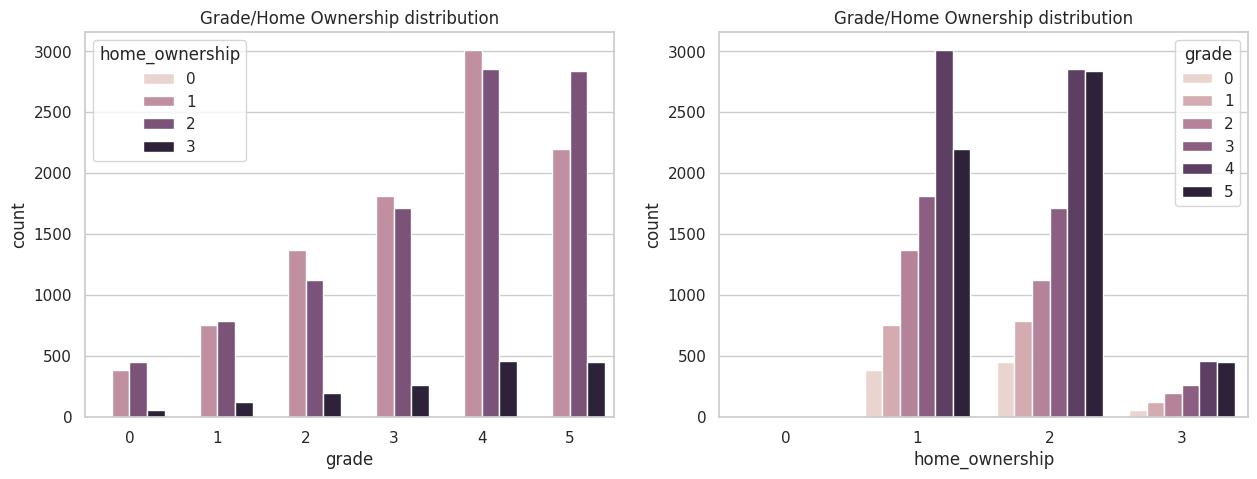

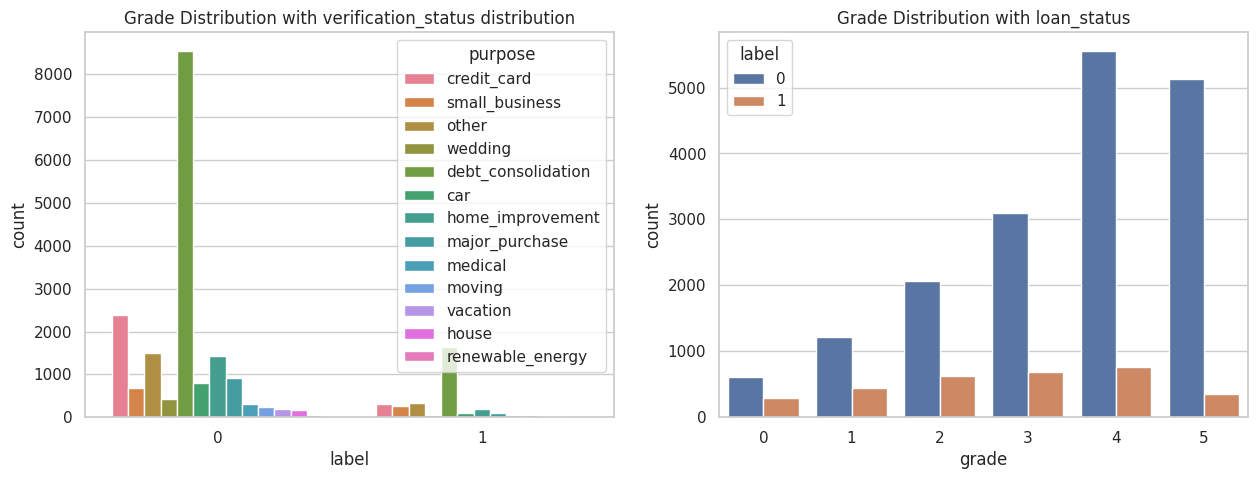

In [ ]:
fig, ax = plt.subplots(1,2,figsize=(15,5))
sns.countplot(data=df_loan, x='grade', hue="home_ownership", ax=ax[0]).set_title("Grade/Home Ownership distribution");
sns.countplot(data=df_loan, x='home_ownership', hue='grade', ax=ax[1]).set_title("Grade/Home Ownership distribution");

fig, ax = plt.subplots(1,2,figsize=(15,5))
sns.countplot(data=df_loan, x='label', hue='purpose', ax=ax[0]).set_title("Grade Distribution with verification_status distribution");
sns.countplot(data=df_loan, x='grade', hue='label', ax=ax[1]).set_title("Grade Distribution with loan_status");

Text(0.5, 1.0, 'Loan amounts grouped by purpose')

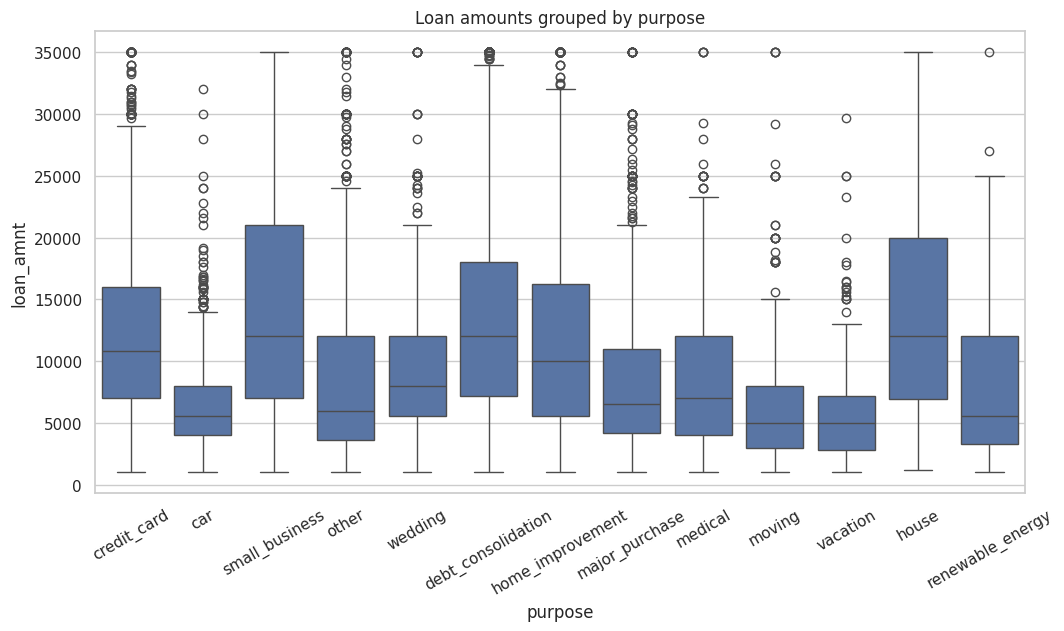

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(x='purpose', y='loan_amnt', data=df_loan)
plt.xticks(rotation=30)
plt.title('Loan amounts grouped by purpose')

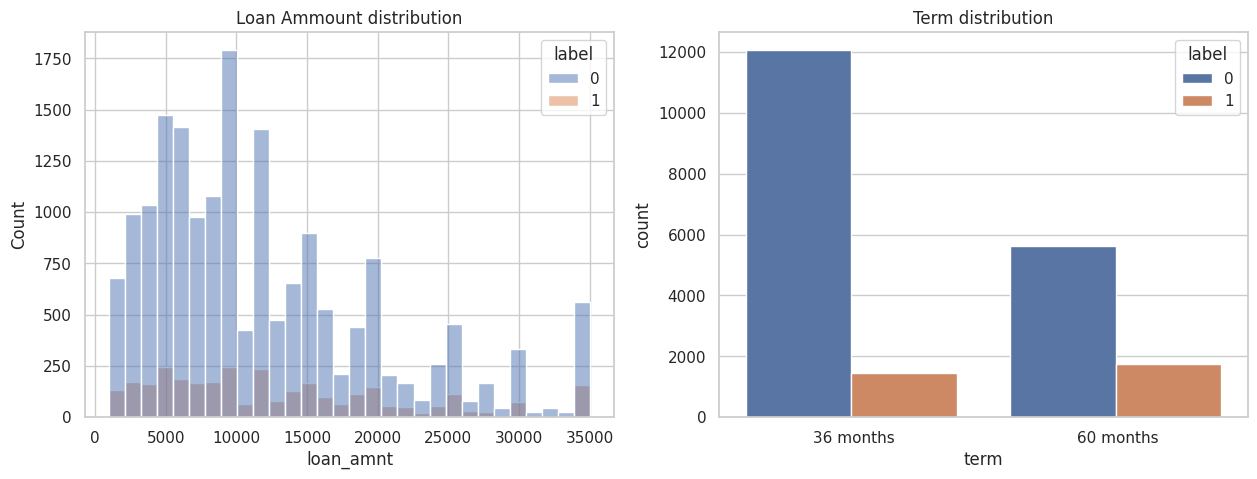

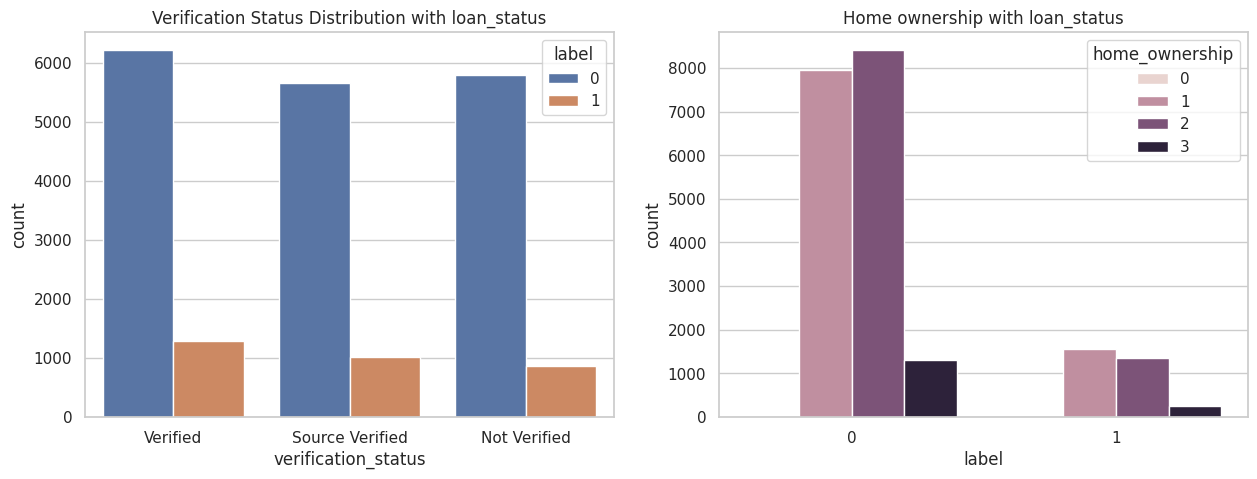

In [ ]:
fig, ax = plt.subplots(1,2,figsize=(15,5))
sns.histplot(df_loan, x='loan_amnt',hue="label", bins=30, ax=ax[0]).set_title("Loan Ammount distribution");
sns.countplot(data=df_loan, x='term', hue="label", ax=ax[1]).set_title("Term distribution");

fig, ax = plt.subplots(1,2,figsize=(15,5))
sns.countplot(data=df_loan, hue='home_ownership', x='label', ax=ax[1]).set_title("Home ownership with loan_status");
sns.countplot(data=df_loan, x='verification_status', hue='label', ax=ax[0]).set_title("Verification Status Distribution with loan_status");

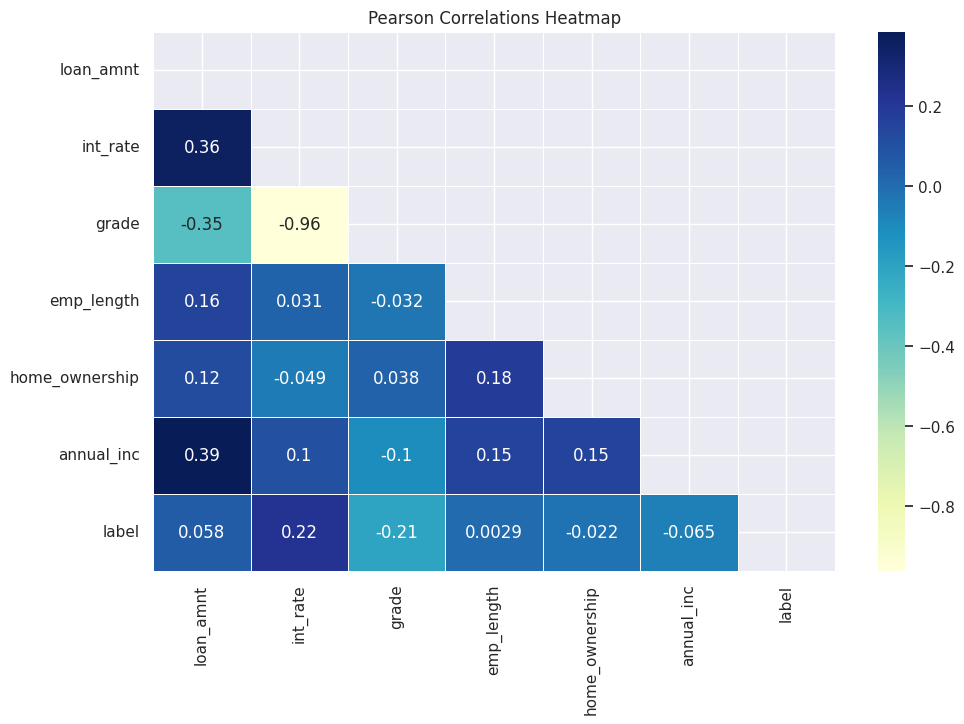

In [ ]:
corr = df_loan[['loan_amnt', 'int_rate', 'grade', 'emp_length', 'home_ownership', 'annual_inc','label']].corr()
sns.set(rc={'figure.figsize':(11,7)})
# Change np.bool to bool to fix the error
sns.heatmap(corr,linewidths=.5, annot=True, cmap="YlGnBu",mask=np.triu(np.ones_like(corr, dtype=bool)))\
    .set_title("Pearson Correlations Heatmap");

In [ ]:
# use LabelEncoder() to encode another category column:
for col in ["verification_status", "purpose","term"]:
    le = LabelEncoder()
    le.fit(df_loan[col])
    df_loan[col] = le.transform(df_loan[col])
df_loan.head()

,loan_amnt,term,int_rate,installment,grade,emp_length,home_ownership,annual_inc,verification_status,purpose,label
0,5000.0,0,10.65,162.87,4,12,1,24000.0,2,1,0
1,2500.0,1,15.27,59.83,3,1,1,30000.0,1,0,1
2,2400.0,0,15.96,84.33,3,12,1,12252.0,0,10,0
3,10000.0,0,13.49,339.31,3,12,1,49200.0,1,8,0
4,3000.0,1,12.69,67.79,4,2,1,80000.0,1,8,0


In [ ]:
df_loan.isnull().sum()

,0
loan_amnt,0
term,0
int_rate,0
installment,0
grade,0
emp_length,0
home_ownership,0
annual_inc,0
verification_status,0
purpose,0


In [ ]:
df_loan.label = df_loan.label.fillna(1)

In [ ]:
X, y = df_loan.drop("label", axis=1), df_loan["label"]

In [ ]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.20, random_state=0)

In [ ]:
max_score = 0
max_k = 0
best_accuracy = 0

for k in range(1, 100):
    neigh = KNeighborsClassifier(n_neighbors=k)
    neigh.fit(X_train,y_train)

    # Tahmin yap
    y_pred = neigh.predict(X_test)

    # F1 skoru hesapla
    score = f1_score(y_test, y_pred,average='micro')


   # En iyi k'yı ve skoru takip et
    if score > max_score:
      max_k = k
      max_score = score

print(f"Best k: {max_k}, Max F1 Score: {max_score}")

Best k: 28, Max F1 Score: 0.8495681381957774
